# Dataset exploration
Distribution des classes et exemples visuels.

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import cv2

data_root = "../data/dataset_tomato"
classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

counts = {}
for cls in classes:
    cls_path = os.path.join(data_root, cls)
    counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

print(counts)

{'Tomato_Bacterial_spot': 2127, 'Tomato_Early_blight': 1000, 'Tomato_Late_blight': 1909, 'Tomato_Leaf_Mold': 952, 'Tomato_Septoria_leaf_spot': 1771, 'Tomato_Spider_mites_Two_spotted_spider_mite': 1676, 'Tomato__Target_Spot': 1404, 'Tomato_healthy': 1591}


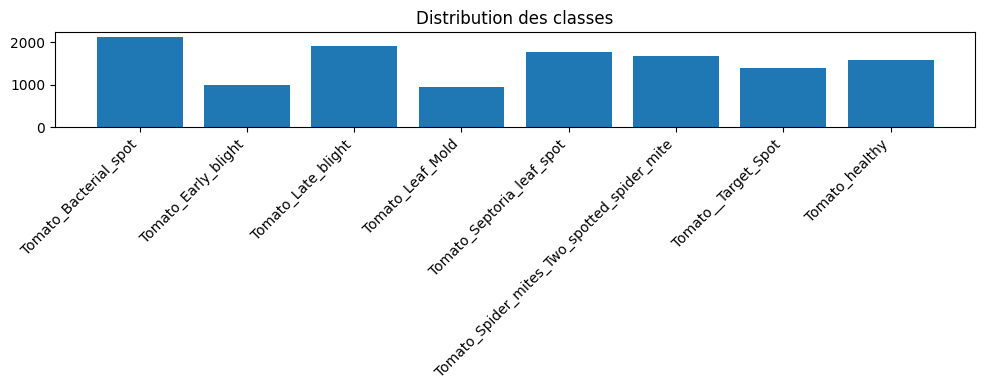

In [4]:
plt.figure(figsize=(10,4))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=45, ha="right")
plt.title("Distribution des classes")
plt.tight_layout()
plt.show()


## Exemples visuels par classe
Verifier la variabilite des images (lumiere, bruit, taille, fonds).

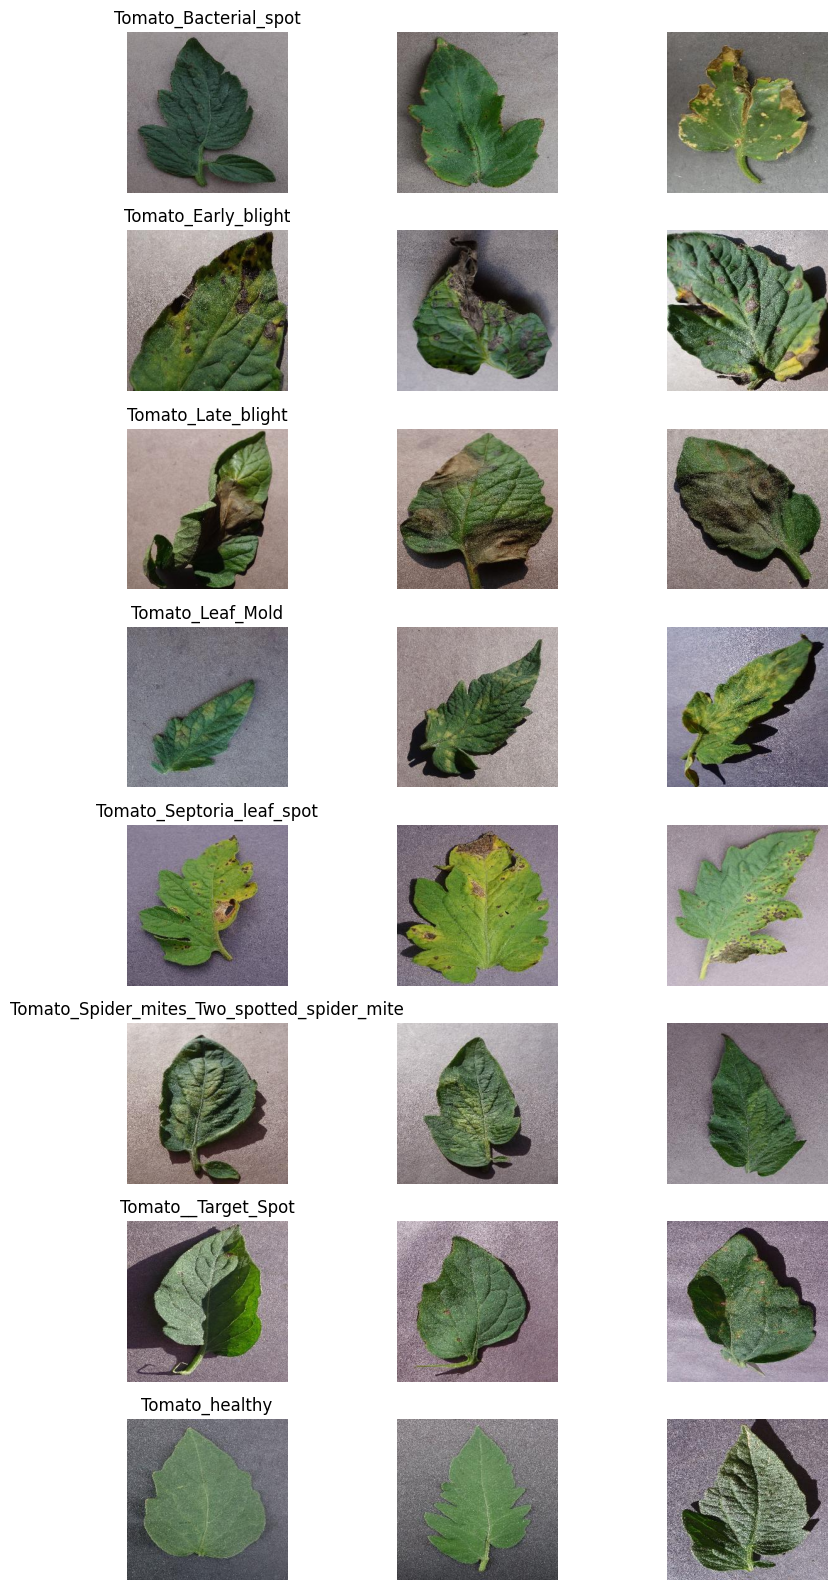

In [5]:
fig, ax = plt.subplots(len(classes), 3, figsize=(9, 2 * len(classes)))

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_root, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:3]
    for j, img_name in enumerate(images):
        img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
        ax[i, j].imshow(img)
        ax[i, j].axis("off")
        if j == 0:
            ax[i, j].set_title(cls)

plt.tight_layout()
plt.show()

## Preuve visuelle: impact des filtres
Comparaison visuelle entre image originale, filtrage Gaussian et filtrage Median.

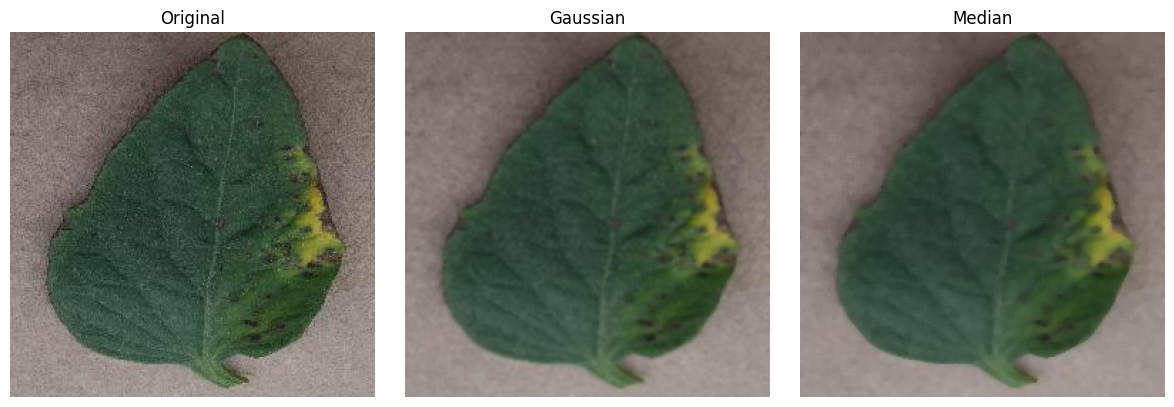

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

sample_class = classes[0]
sample_dir = os.path.join(data_root, sample_class)
sample_img = [f for f in os.listdir(sample_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))][6]
sample_path = os.path.join(sample_dir, sample_img)

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gauss = cv2.GaussianBlur(img_rgb, (5, 5), 0)
img_median = cv2.medianBlur(img_rgb, 5)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb); ax[0].set_title("Original")
ax[1].imshow(img_gauss); ax[1].set_title("Gaussian")
ax[2].imshow(img_median); ax[2].set_title("Median")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

## Interpretation des filtres
Sur cette image, le filtrage Gaussian reduit legerement le bruit tout en preservant les zones de maladie visibles.
Le filtrage Median lisse davantage la texture, ce qui risque d effacer des details fins utiles a la classification.
Conclusion: on retient un Gaussian leger (k=5) uniquement si le bruit est present, sinon on conserve l image originale pour garder toute la texture.

## Preuve visuelle: comparaison des segmentations
Comparaison des masques Otsu, HSV et K-means sur la meme image.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Otsu threshold
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
_, mask_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# HSV threshold
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
lower = np.array([20, 40, 40])
upper = np.array([90, 255, 255])
mask_hsv = cv2.inRange(hsv, lower, upper)

# K-means segmentation
Z = img_rgb.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
_, labels, centers = cv2.kmeans(Z, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = centers.astype(np.uint8)
seg_kmeans = centers[labels.flatten()].reshape(img_rgb.shape)

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(img_rgb); ax[0].set_title("Original")
ax[1].imshow(mask_otsu, cmap="gray"); ax[1].set_title("Otsu mask")
ax[2].imshow(mask_hsv, cmap="gray"); ax[2].set_title("HSV mask")
ax[3].imshow(seg_kmeans); ax[3].set_title("K-means")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

NameError: name 'sample_path' is not defined

## Interpretation des segmentations
Le masque Otsu est tres bruité et conserve beaucoup de fond, ce qui n est pas ideal pour isoler la feuille.
Le masque HSV suit bien les contours de la feuille et supprime la majorite du fond, donc il est plus stable.
Le K-means donne un resultat intermediaire, mais depend davantage des conditions d eclairage.
Conclusion: on retient HSV comme segmentation finale, Otsu comme baseline et K-means comme alternative en cas de fond complexe.